# Uniform Piecewise Surface Template with Two Zones

This notebook shows how to build a simple **piecewise‑uniform** 2D PDF that:
1. Is constant within the $1\sigma$ contour (region $\Sigma_1$).
2. Is constant in the annular region between the $1\sigma$ and $2\sigma$ contours ($\Sigma_2$ \ $\Sigma_1$).
3. Has zero probability outside the $2\sigma$ contour ($\Sigma_2$).

We enforce that 68% of the total events lie inside $\Sigma_1$, and the remaining 32% lie in the annulus.  This yields closed‑form densities:
$$
f(x,y) 
= 
\begin{cases}
c_0 \;=\; 0.68 / A_1, & (x,y) \in \Sigma_1,\\
c_1 \;=\; 0.32 / (A_2 - A_1), & (x,y) \in \Sigma_2 \setminus \Sigma_1,\\
0, & (x,y) \notin \Sigma_2,
\end{cases}
$$
where $A_1 = \mathrm{Area}(\Sigma_1)$ and $A_2 = \mathrm{Area}(\Sigma_2)$.

We then use **rejection sampling** to generate random points following this PDF within the $2\sigma$ bounding box.


## 1. Imports and Helper Functions
We need NumPy, Matplotlib, and Shapely to load contours, compute areas, and sample points.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
import random
from multihist import Histdd
import inference_interface

experiment = "xenonnt_sr0"
bkg = "surface"

## 2. Load Contour Data and Build Polygons
- We assume two CSV files contain the 1σ and 2σ boundary points.
- We normalize cS1 → [0,1] and log₁₀(cS2) → [0,1] as before.
- Build Shapely `Polygon` objects: `poly1` for Σ₁, `poly2` for Σ₂.


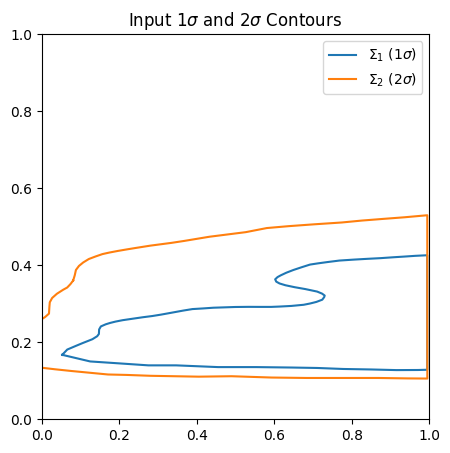

In [2]:
# ROI normalization bounds
x_min, x_max = 0.0, 1.0
y_min, y_max = 0.0, 1.0

# Load published CSV files (normalized cS1,cS2) for contours
one_sigma = np.loadtxt(f"../diamx/data/{experiment}_{bkg}_1sigma.csv", delimiter=",")
two_sigma = np.loadtxt(f"../diamx/data/{experiment}_{bkg}_2sigma.csv", delimiter=",")
# Normalize: cS1/100 → [0,1], log10(cS2)/2 - 1.05 → [0,1]
one_sigma[:, 0] = one_sigma[:, 0] / 100.0
one_sigma[:, 1] = np.log10(one_sigma[:, 1]) / 2.0 - 1.05
two_sigma[:, 0] = two_sigma[:, 0] / 100.0
two_sigma[:, 1] = np.log10(two_sigma[:, 1]) / 2.0 - 1.05

# Create Shapely polygon objects (ensure vertices are ordered)
poly1 = Polygon(one_sigma)
poly2 = Polygon(two_sigma)

# Visualize the input polygons
plt.figure(figsize=(5, 5))
plt.plot(*poly1.exterior.xy, label=r"$\Sigma_1$ (1$\sigma$)")
plt.plot(*poly2.exterior.xy, label=r"$\Sigma_2$ (2$\sigma$)")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.legend()
plt.title(r"Input 1$\sigma$ and 2$\sigma$ Contours")
plt.show()

## 3. Compute Areas and Define Densities
Compute the areas $A_1$ and $A_2$ of $\Sigma_1$ and $\Sigma_2$, then set:
- $c_0 = 0.68 / A_1$
- $c_1 = 0.32 / (A_2 - A_1)$


In [3]:
# Compute areas
A1 = poly1.area
A2 = poly2.area
print(f"Area Σ₁ = {A1:.5f}, Area Σ₂ = {A2:.5f}, Shell area = {A2 - A1:.5f}")

# Densities
c0 = 0.68 / A1
c1 = 0.32 / (A2 - A1)
print(f"c0 (inside Σ₁) = {c0:.5f}, c1 (between Σ₁ and Σ₂) = {c1:.5f}")

Area Σ₁ = 0.17044, Area Σ₂ = 0.35409, Shell area = 0.18366
c0 (inside Σ₁) = 3.98979, c1 (between Σ₁ and Σ₂) = 1.74237


## 4. Rejection Sampling
We sample points uniformly in the bounding box of Σ₂, then reject if outside Σ₂, and accept with probability:
- 1 if inside Σ₁ (since density = c0),
- \(c_1/c_0\) if in the shell Σ₂\Σ₁ (since density there is c1).
This yields the correct piecewise‐uniform PDF.

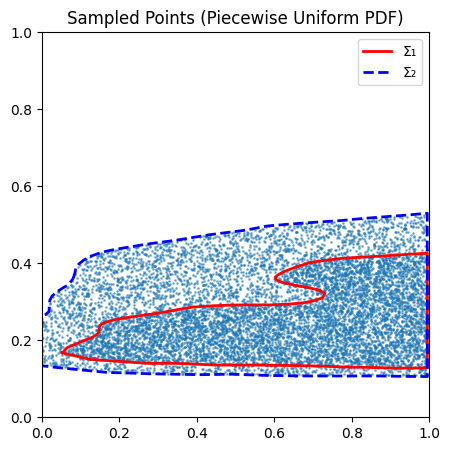

In [4]:
# Precompute acceptance ratio
ratio = c1 / c0

# Bounding box of \Sigma_2
minx, miny, maxx, maxy = poly2.bounds


def sample_point():
    """Generate one sample from the piecewise-uniform PDF."""
    while True:
        x = random.uniform(minx, maxx)
        y = random.uniform(miny, maxy)
        pt = Point(x, y)
        # Reject outside \Sigma_2
        if not poly2.contains(pt):
            continue
        # Inside \Sigma_1: accept
        if poly1.contains(pt):
            return x, y
        # In shell: accept with prob c1/c0
        if random.random() < ratio:
            return x, y
        # otherwise, reject and retry


# Example: draw 10,000 samples
N = 10000
samples = np.zeros((N, 2))
for i in range(N):
    samples[i] = sample_point()

# Plot the sampled points
plt.figure(figsize=(5, 5))
plt.scatter(samples[:, 0], samples[:, 1], s=1, alpha=0.5)
plt.plot(*poly1.exterior.xy, color="red", linewidth=2, label="Σ₁")
plt.plot(*poly2.exterior.xy, color="blue", linestyle="--", linewidth=2, label="Σ₂")
plt.legend()
plt.title("Sampled Points (Piecewise Uniform PDF)")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.show()

## 5. Verify Proportions
Check that approximately 68% of the samples lie inside Σ₁ and 32% in the shell.

In [5]:
# Count how many fall inside Σ₁ vs shell
pts_shapely = [Point(pt) for pt in samples]
inside1 = np.array([poly1.contains(pt) for pt in pts_shapely])
inside2 = np.array([poly2.contains(pt) for pt in pts_shapely])

frac1 = inside1.mean()
frac2 = (~inside1 & inside2).mean()
print(f"Fraction inside Σ₁: {frac1:.3f} (should ≈ 0.68)")
print(f"Fraction in shell (Σ₂\Σ₁): {frac2:.3f} (should ≈ 0.32)")

Fraction inside Σ₁: 0.683 (should ≈ 0.68)
Fraction in shell (Σ₂\Σ₁): 0.317 (should ≈ 0.32)


## Convert to diamx Template

In [7]:
N = 1000000
events = np.zeros((N, 2))
for i in range(N):
    events[i] = sample_point()

mh = Histdd(
    events[:, 0] * 100,
    10 ** (events[:, 1] * 2 + 2.1),
    bins=[np.linspace(0, 100, 101), np.logspace(2.6020599913279625, 4.1, 81)],
    axis_names=["cs1", "cs2"],
)
mh.histogram /= mh.histogram.sum()
inference_interface.multihist_to_template(
    [mh],
    f"../diamx/data/{experiment}_{bkg}_template_contour_driven_400PE.h5",
    ["cs1-cs2"],
)